<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA1_TP2/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_2%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**INTELIGENCIA COMPUTACIONAL**
##IC415
###RA1 - Trabajo Práctico N°2
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/01_introduccion_eda.ipynb)

##Objetivos
Desarrollar la capacidad de inspeccionar, comprender e interpretar conjuntos de datos mediante técnicas
de Análisis Exploratorio de Datos (EDA, por sus siglas en inglés). Aplicar herramientas estadísticas y
visuales para identificar patrones, anomalías y relaciones entre variables. Formular hipótesis
fundamentadas a partir de la evidencia observada en los datos, construyendo una intuición analítica que
sirva de base para etapas posteriores de modelado.
Afianzar la capacidad de comunicación de procedimientos y hallazgos técnicos de forma clara y
estructurada, justificando la toma de decisiones en base a la información obtenida.

##Consignas:
###Ejercicio 1 - Comprensión inicial de datos reales
Una empresa inmobiliaria desea comprender mejor el mercado de viviendas de su región. Para apoyar
sus decisiones comerciales, cuenta con un registro histórico de propiedades que incluye variables como
precio de venta, superficie total, cantidad de habitaciones, antigüedad del inmueble, barrio, entre otras.
El dataset se encuentra en el archivo adjunto denominado “propiedades.csv”. En la Tabla 1, se presenta
un fragmento representativo.


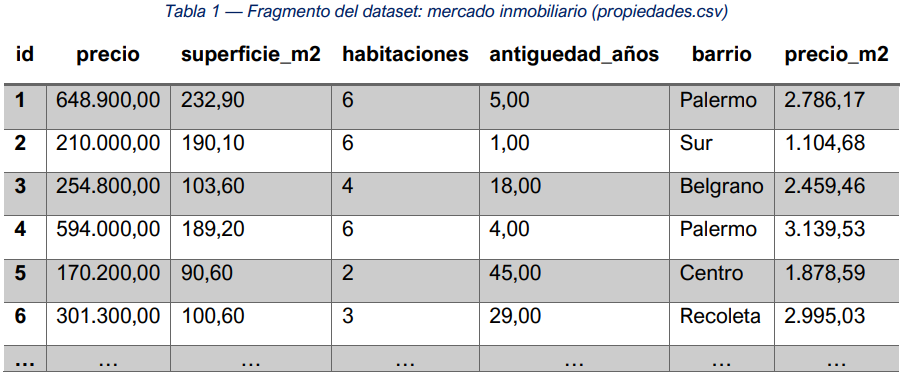

---
##Adiciones necesarias para la resolución del enunciado

---

In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


In [ ]:
# Importación de librerías específicas para este notebook
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore') # Mantenemos los logs limpios

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Esta función engloba código reutilizable para la gestión y carga de los datos
from utils.data import load_dataset

dataset_path = "/content/drive/MyDrive/datasets/immobiliaria/propiedades.csv"
dataset = pd.read_csv(dataset_path)


---

El objetivo de este ejercicio es realizar una exploración inicial completa del dataset. Para ello, se propone
recorrer las siguientes dimensiones de análisis, respondiendo como mínimo las consignas indicadas:

---


###Comprensión estructural del dataset
- ¿Qué representa cada fila del datset?¿Y Cada columna?

In [ ]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
dataset.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


Cada **fila** representa un registro histórico único de una propiedad inmobiliaria particular puesta a la venta en la región.

Cada **columna** representa una característica o atributo específico de esa propiedad (como el precio de venta o superficie total por ejemplo). La columna `id` es simplemente un identificador único para cada registro.

- ¿Qué tipos de variables están presentes (numéricas continuas, discretas, categóricas)?

Los tipos de variables presentes son los siguientes:

*   `id`: Identificador único.
*   `precio`, `superficie_m2`, `precio_m2`, `antiguedad_años`: variables numericas continuas.
*   `habitaciones`: variable numerica discreta.
*   `barrio`: variable categórica.




- ¿Todas las variables tienen el mismo tipo de dato correcto en el *dataframe*?

No del todo. Si bien las variables continuas (`precio`, `superficie_m2`, `precio_m2`) y categóricas (`barrio`) tienen tipos de datos computacionales correctos (float64 y object), se detectó una discrepancia en la variable `antiguedad_años`.

Desde la teoría estadística, la antigúedad en años es una variable **numérica discreta**, por lo que su tipo computacional ideal debería ser entero (`int64`). Sin embargo, el método `.info()` revela que está cargada como `float64`.

Nuestra hipótesis es que esta anomalía se debe a la presencia de valores nulos en dicha columna (solo posee 752 valores no nulos sobre 800). En la arquitectura de Pandas, la inclusión de valores `NaN` fuerza a que toda columna convierta a punto flotante. para corregir este tipo de dato, primero se deberá tomar una decisión sobre cómo tratar o imputar estos valores faltantes en la etapa de Calidad de Datos.


- ¿Cuántas instancias contiene el dataset?

Haciendo uso del metodo `.info()` se evidencian 800 instancias (`entries`, filas) y 7 variables (columnas).

In [ ]:
# Resumen de los tipos de datos y recuento de valores no nulos
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


- ¿La cantidad es suficiente para sacar conclusiones?

Sí. En el contexto de un Análisis Explotariorio de Datos (EDA) inicial para un mercado inmobiliario regional, 800 observaciones es un volumen estadísticamente decente. Esta cantidad nos permite realizar agrupaciones decente. Esta cantidad nos permite realizar agrupaciones, calcular medidas de tendencia central, de dispersión de confianza, y construir una intuición analítica sólida sin que valores extremos (outliers) distorsiones fuertemente las conclusiones generales.

###Visualización y detección de outliers

- Analizar la distribución de al menos tres variables numéricas utilizando histogramas y boxplots.

Las tres variables numéricas para su análisis serán `precio`, `superficie_m2` y `precio_m2`.

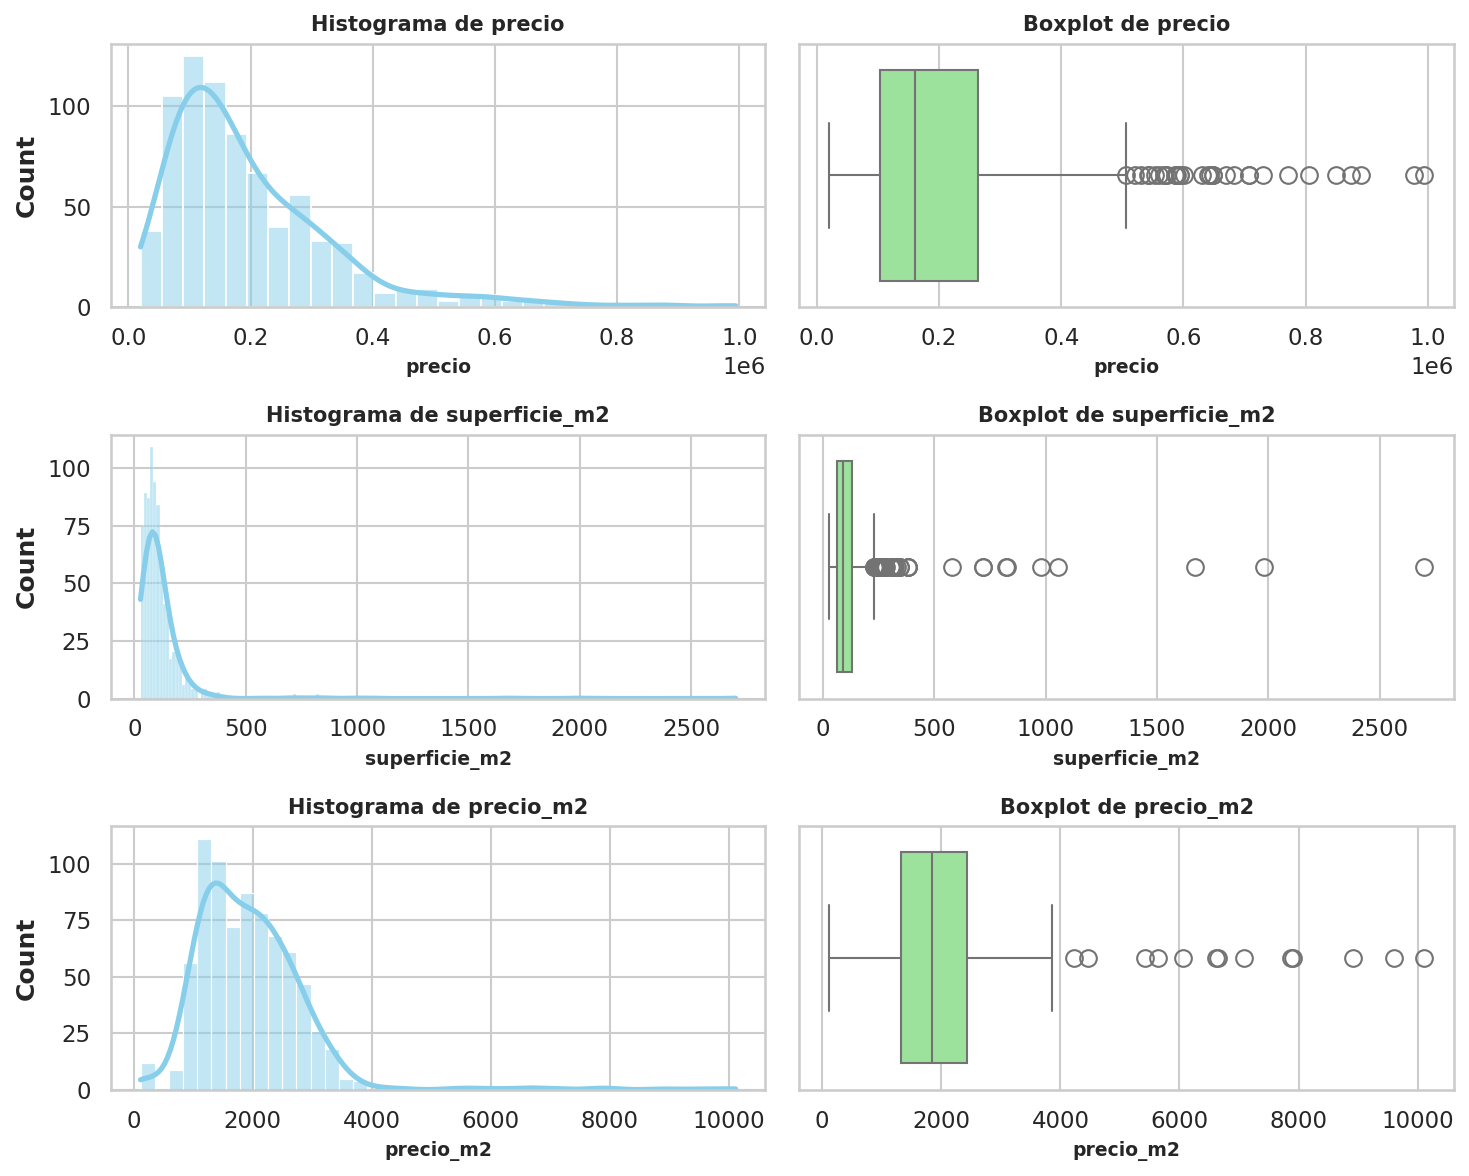

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# carga de las 3 variables a analizar
variables = ['precio', 'superficie_m2', 'precio_m2']

# Se definen parametros para la creación de la visualización
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

# bucle que itera entre gráfico por variable
for i, var in enumerate(variables):

    # gráfico izquierdo (Columna 0): Histograma
    sns.histplot(data=dataset, x=var, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histograma de {var}', fontsize=10)
    axes[i, 0].set_xlabel(var, fontsize=9)

    # gráfico derecho (Columna 1): Boxplot
    sns.boxplot(data=dataset, x=var, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {var}', fontsize=10)
    axes[i, 1].set_xlabel(var, fontsize=9)

# se ajustamos el espaciado para evitar superposiciones
plt.tight_layout()

# impresión del gráfico final
plt.show()

Se puede evidenciar que ninguna de estas variables presenta una distribución normal simétrica. Los histogramas evidencian un fuerte sesgo hacia la derecha, lo que indica que la gran mayoría de las propiedades se concentran en valores bajos a medios, mientras que una minoría se extiende hacia valores extremadamente altos.

Por otro lado, analizando las visualizaciones de los boxplots, se detectan outliers evidentes en todas las variables analizadas.

No todos los outliers detectados estadísticamente deben eliminarse, ya que muchos representan la naturaleza real del dominio del problema.

Por ejemplo, en la variable `precio`, los valores atípicos superiores (cercanos o superior al millón) pueden ser perfectamente legíticmos. Representan propiedades de lujo o grandes terrenos en zonas de prestigio, por lo que eliminarlos significaría perder información valiosa del mercado.

Por el contrario, en la variable `superficie_m2`, el boxplot y el cálculo previo mostraron un valor extremo de mas de 2500 m2. En el contexto de viviendas urbanas estándar, esto es muy sospechoso y probablemente se deba a un error de tipeo (inconsistencia en la carga de datos). Este tipo de anomalías deben ser tratadas o eliminadas, ya que son ruido puro que afectarpa el rendimiento del modelo de IC.





---
parte del colab axel

---

### Carga y Exploración Inicial

Primero, cargamos los datos y damos un "vistazo" rápido a su estructura. Usamos `pandas`, la librería por excelencia para el manejo de datos tabulares en Python.

In [ ]:
# Resumen de los tipos de datos y recuento de valores no nulos
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


Observamos que algunas columnas son de tipo `object` (strings categóricos), otras `int64` (enteros) y `float64` (decimales).
¡Tenemos datos faltantes!
precio 32


In [ ]:
# Descriptores estadísticos básicos para las columnas numéricas
dataset.describe()

,id,precio,superficie_m2,habitaciones,antiguedad_años,precio_m2
count,800.0000,768.000000,800.00000,800.000000,752.000000,768.000000
mean,400.5000,200636.743398,117.63600,3.428750,21.960106,1961.878724
std,231.0844,142582.538365,154.54675,1.625801,18.556668,988.500261
min,1.0000,19900.000000,28.00000,1.000000,0.000000,116.180000
25%,200.7500,102900.000000,62.67500,2.000000,4.000000,1322.425000
50%,400.5000,160000.000000,90.95000,3.000000,18.000000,1841.940000
75%,600.2500,264075.000000,129.27500,5.000000,38.000000,2436.200000
max,800.0000,994200.000000,2700.00000,7.000000,59.000000,10111.360000


### 3. Tratamiento de Datos Faltantes (*Missing Values*)

Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

In [ ]:
# Contabilizar valores nulos por columna
dataset.isna().sum()

,0
id,0
precio,32
superficie_m2,0
habitaciones,0
antiguedad_años,48
barrio,0
precio_m2,32


Según el contexto de nuestro problema (ver tarjeta del *dataset* en [*ACV Dataset*](https://github.com/AxelSkrauba/applied-ai-engineering/blob/main/datasets/acv/README.md)), en la variable `estado_fumador`, la categoría "desconocido" se utilizó para las entradas donde no había información. **Esto es funcionalmente un dato faltante** disfrazado de categoría. Vamos a exponerlo como tal para tratarlo correctamente.

In [ ]:
# Reemplazamos "desconocido" por el valor nulo estándar de numpy (np.nan)
dataset['estado_fumador'] = dataset['estado_fumador'].replace('desconocido', np.nan)

# Calculamos el porcentaje de valores perdidos
miss_val_pct = dataset.isnull().sum() / len(dataset) * 100
print("Porcentaje de valores faltantes:")
print(miss_val_pct[miss_val_pct > 0].apply(lambda x: f"{x:.2f}%"))

KeyError: 'estado_fumador'

Para variables numéricas con bajo porcentaje de faltantes (como el `imc`, ~3.9%), una práctica común es **imputar** (rellenar) esos huecos con la **mediana** de la distribución, ya que es más robusta a *outliers* que la media.

Para variables categóricas con un alto porcentaje (como `estado_fumador`, ~30%), la decisión es más difícil. Podríamos imputar con la moda (el más frecuente), pero estaríamos sesgando mucho los datos. En este ejemplo didáctico, optaremos por **eliminar** las filas que no tengan esta información.

*Nota: En un escenario real estricto, descartar el 30% de los datos duele (en sentido figurado, por las dudas...). Se podrían usar técnicas avanzadas de imputación (ej: predecir el estado fumador basado en la edad y enfermedades).*

In [ ]:
# 1. Imputación de IMC con la mediana
mediana_imc = dataset['imc'].median()
dataset['imc'] = dataset['imc'].fillna(mediana_imc)

# 2. Descarte de filas con 'estado_fumador' nulo
dataset = dataset.dropna(subset=['estado_fumador'])

print(f"Filas restantes después de la limpieza: {len(dataset)}")
print(f"Valores nulos restantes:\n{dataset.isna().sum().sum()}")

### 4. Análisis de Distribuciones y Desbalance

Vamos a explorar cómo se distribuyen nuestras variables categóricas, prestando especial atención a nuestra variable objetivo (`apoplejia`).

In [ ]:
# Gráfico de pastel para el estado laboral
plt.figure(figsize=(6, 6))
dataset['tipo_trabajo'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set3', ylabel='')
plt.title('Distribución por Tipo de Trabajo')
plt.show()

In [ ]:
# Verificamos el balance de nuestra variable a predecir
plt.figure(figsize=(6, 4))
sns.countplot(data=dataset, x='apoplejia', palette='pastel')
plt.title('Distribución de Casos de ACV (0=No, 1=Sí)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

casos_positivos = (dataset['apoplejia'] == 1).sum()
pct_positivos = casos_positivos / len(dataset) * 100
print(f"Casos positivos de ACV: {casos_positivos} ({pct_positivos:.2f}%)")

**¡Alerta de Desbalance!** ⚠️

Notamos que los casos positivos (ACV) representan una fracción mínima del *dataset* (apenas un ~5.6%). Este es un escenario muy común en salud, detección de fraudes y mantenimiento predictivo.
Si entrenamos un modelo así, probablemente aprenderá a predecir siempre "0" y logrará un 94% de precisión (Accuracy), siendo completamente inútil. En fases posteriores (Modelado) abordaremos técnicas como el submuestreo o SMOTE para lidiar con esto.

### 5. Detección de Valores Atípicos (*Outliers*)

Los *outliers* son valores que se desvían drásticamente del resto de la distribución. Pueden ser errores de carga de datos o anomalías reales muy raras. Usamos diagramas de caja (*Boxplots*) para detectarlos visualmente en las variables continuas.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=dataset['edad'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')

sns.boxplot(y=dataset['nivel_glucosa'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Nivel de Glucosa')

sns.boxplot(y=dataset['imc'], ax=axes[2], color='salmon')
axes[2].set_title('Distribución de IMC')

plt.tight_layout()
plt.show()

Observamos que no hay *outliers* evidentes en `edad`, pero sí muchos valores extremos altos en `nivel_glucosa` e `imc`.
*   Un `imc` cercano a 80-90 es biológicamente extremo (aunque posible en obesidad mórbida severa), pero podría ser un error tipográfico.
*   Un nivel de glucosa superior a 200 indica diabetes severa, lo cual es real y un fuerte factor de riesgo para ACV, por lo que **no deberíamos eliminarlos ciegamente**.

Para este ejercicio, filtramos (a modo de ejemplo) solo los valores de `imc` extremadamente dudosos (> 60).

In [ ]:
# Descarte condicional
dataset = dataset[dataset['imc'] <= 60]
print(f"Filas tras eliminar outliers de IMC: {len(dataset)}")

### 6. Relaciones entre Variables (Correlación)

Para entender cómo se relacionan las variables entre sí, podemos usar una matriz de correlación. Sin embargo, matemáticamente la correlación estándar (Pearson) se aplica a valores numéricos. Por lo tanto, debemos transformar nuestras variables categóricas (*strings*) a números temporales.

#### Tipos de Correlación (Mini Teoría)
- **Pearson**: Mide relaciones lineales. Ideal para distribuciones normales continuas.
- **Spearman**: Basado en rangos. Útil para relaciones monótonas (si uno sube, el otro también, pero no necesariamente en línea recta) o si hay muchos outliers.
- **Kendall**: Similar a Spearman, pero más robusto cuando el dataset es pequeño o hay muchos "empates" de valores.

Vamos a codificar rápidamente las categóricas usando `LabelEncoder` de `scikit-learn`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

dataset_encoded = dataset.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

En el mapa de calor, buscamos valores cercanos a 1 (correlación positiva fuerte) o -1 (correlación negativa fuerte).
*   Observamos una alta correlación (0.68) entre la `edad` y `casado_alguna_vez`. ¡Tiene todo el sentido lógico!
*   La variable objetivo `apoplejia` tiene sus mayores correlaciones positivas con la `edad` (0.24), el `nivel_glucosa` (0.13) y la presencia de `hipertension` (0.14) o `enfermedad_corazon` (0.14). Esto nos confirma que estas variables serán predictoras importantes para nuestros futuros modelos.

**NOTA**: para entender mejor las correlaciones, explorar el notebook [Análisis de Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb)

## Resultados y Discusión

A partir de este EDA básico, hemos concluido que:
1. Nuestro *dataset* sufre de un **fuerte desbalance de clases**, requiriendo atención especial en la fase de modelado.
2. Identificamos y tratamos datos faltantes de manera fundamentada (imputación por mediana para numéricos, descarte para categóricos).
3. Confirmamos mediante correlaciones que factores biológicos como la edad, la glucosa y condiciones cardíacas preexistentes están ligados a la probabilidad de un ACV en nuestros datos.
4. Identificamos que variables como el `id` no aportan información y solo introducen ruido.

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** [Feature Engineering y Limpieza de Datos](02_feature_engineering_y_limpieza.ipynb).
- 🔄 **Relacionado:** Con el dataset limpio, estamos listos para entender qué hacen los modelos con esto [Introducción a la Clasificación](../03_machine_learning/01_introduccion_clasificacion.ipynb).

## Referencias
1. Dataset ACV: Healthcare Dataset Stroke Data (Kaggle).
2. [Documentación Oficial de Pandas](https://pandas.pydata.org/docs/)
3. [Documentación de Seaborn para Visualización Estadística](https://seaborn.pydata.org/)

---
## Entorno de Ejecución

In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)